<a href="https://colab.research.google.com/github/priyal6/EDA/blob/main/statistical_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import numpy as np
import pandas as pd
from scipy import stats
from scipy import stats
from scipy.stats import ttest_ind, mannwhitneyu, f_oneway, chi2_contingency
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score



In [ ]:
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1000)

np.random.seed(42)

In [ ]:
FILE_PATH = "sales_data.csv"

def generate_sample_data(n=500):
  dates = pd.date_range(start="2026-01-01", periods=n, freq="D")
  products = np.random.choice(["Laptop", "Phone", "Tablet", "Monitor", "Keyboard"], size = n)
  categories = np.random.choice(["Electronics", "Accessories"], size=n, p=[0.7, 0.3])
  regions = np.random.choice(["North", "South", "East", "West"], size=n)
  quantity = np.random.randint(1, 11, size=n)
  discount = np.round(np.random.choice([0.00, 0.05, 0.10, 0.15, 0.20, 0.25, 0.30], size=n), 2)


  product_price_map = {
        "Laptop": 1200,
        "Phone": 800,
        "Tablet": 500,
        "Monitor": 300,
        "Keyboard": 80
    }

  base_price = np.array([product_price_map[p] for p in products])


  sales = base_price * quantity * (1 - discount) + np.random.normal(0, 100, size=n)


  profit = (sales * np.random.uniform(0.08, 0.22, size=n)) - (discount * 200) + np.random.normal(0, 40, size=n)

  df = pd.DataFrame({
        "Date": dates,
        "Product": products,
        "Category": categories,
        "Region": regions,
        "Sales": np.round(sales, 2),
        "Profit": np.round(profit, 2),
        "Discount": discount,
        "Quantity": quantity
    })


  for col in ["Sales", "Profit", "Discount"]:
        idx = np.random.choice(df.index, size=5, replace=False)
        df.loc[idx, col] = np.nan

  return df

if os.path.exists(FILE_PATH):
    df = pd.read_csv(FILE_PATH)
    print(f"Loaded dataset from {FILE_PATH}")
else:
    df = generate_sample_data(n=500)
    print("sales_data.csv not found. Generated sample dataset.")

sales_data.csv not found. Generated sample dataset.


In [ ]:
print(df.head())

        Date  Product     Category Region    Sales   Profit  Discount  Quantity
0 2026-01-01   Tablet  Accessories  North  3794.27   472.70      0.10         8
1 2026-01-02    Phone  Accessories   East  4151.59   374.50      0.25         7
2 2026-01-03   Laptop  Electronics   West  2313.93   346.59      0.30         3
3 2026-01-04  Monitor  Electronics  South   567.90    25.53      0.15         2
4 2026-01-05   Laptop  Electronics   West  6859.00  1317.34      0.20         7


In [ ]:
print(df.shape)

(500, 8)


In [ ]:
print(df.dtypes)

Date        datetime64[ns]
Product             object
Category            object
Region              object
Sales              float64
Profit             float64
Discount           float64
Quantity             int64
dtype: object


In [ ]:
print(df.isnull().sum())

Date        0
Product     0
Category    0
Region      0
Sales       5
Profit      5
Discount    5
Quantity    0
dtype: int64


In [ ]:
# data cleaning
df['Date'] = pd.to_datetime(df['Date'], errors="coerce")

num_cols = ["Sales", "Profit", "Discount"]
for col in num_cols:
  if col in df.columns:
    df[col] = df[col].fillna(df[col].median())

In [ ]:
df.dropna(subset=["Date", "Product", "Category", "Region"], inplace=True)

In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
# after cleaning
print(df.isnull().sum())
print("Shape after cleaning:", df.shape)

Date        0
Product     0
Category    0
Region      0
Sales       0
Profit      0
Discount    0
Quantity    0
dtype: int64
Shape after cleaning: (500, 8)


In [ ]:
# feature engineering
df['Month'] = df['Date'].dt.to_period("M").astype(str)
df['High_Discount'] = np.where(df['Discount'] > 0.15, "Yes", "No")
df["Profit_Margin"] = np.where(df["Sales"] != 0, df["Profit"] / df["Sales"], 0)

In [ ]:
df.head()

,Date,Product,Category,Region,Sales,Profit,Discount,Quantity,Month,High_Discount,Profit_Margin
0,2026-01-01,Tablet,Accessories,North,3794.27,472.70,0.10,8,2026-01,No,0.124583
1,2026-01-02,Phone,Accessories,East,4151.59,374.50,0.25,7,2026-01,Yes,0.090206
2,2026-01-03,Laptop,Electronics,West,2313.93,346.59,0.30,3,2026-01,Yes,0.149784
3,2026-01-04,Monitor,Electronics,South,567.90,25.53,0.15,2,2026-01,No,0.044955
4,2026-01-05,Laptop,Electronics,West,6859.00,1317.34,0.20,7,2026-01,Yes,0.192060


In [ ]:
print("\n===== DESCRIPTIVE STATISTICS =====")
print(df[["Sales", "Profit", "Discount", "Quantity", "Profit_Margin"]].describe())

print("\n===== SKEWNESS =====")
print(df[["Sales", "Profit", "Discount", "Quantity"]].skew())

print(df[["Sales", "Profit", "Discount", "Quantity"]].skew())

print("\n===== KURTOSIS =====")
print(df[["Sales", "Profit", "Discount", "Quantity"]].kurtosis())

print("\n===== REGION-WISE SALES =====")
print(df.groupby("Region")["Sales"].agg(["count", "mean", "median", "std", "min", "max"]).sort_values("mean", ascending=False))

print("\n===== CATEGORY-WISE PROFIT =====")
print(df.groupby("Category")["Profit"].agg(["count", "mean", "median", "std"]).sort_values("mean", ascending=False))


===== DESCRIPTIVE STATISTICS =====
             Sales       Profit    Discount    Quantity  Profit_Margin
count    500.00000   500.000000  500.000000  500.000000     500.000000
mean    2578.88540   349.118960    0.158300    5.472000       0.078813
std     2485.74457   404.730489    0.100729    2.947302       0.849785
min     -138.47000  -144.960000    0.000000    1.000000     -13.143939
25%      590.21250    72.672500    0.050000    3.000000       0.078487
50%     1948.01000   229.740000    0.150000    6.000000       0.121959
75%     3702.89250   502.842500    0.250000    8.000000       0.173144
max    12169.36000  2245.760000    0.300000   10.000000       6.959184

===== SKEWNESS =====
Sales       1.484092
Profit      1.825264
Discount   -0.101349
Quantity    0.015374
dtype: float64
Sales       1.484092
Profit      1.825264
Discount   -0.101349
Quantity    0.015374
dtype: float64

===== KURTOSIS =====
Sales       2.099866
Profit      3.853216
Discount   -1.246811
Quantity   -1.249288

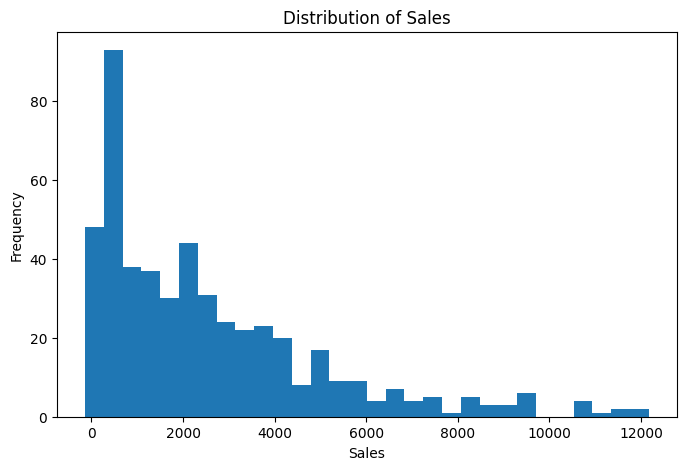

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 5))
plt.hist(df["Sales"], bins=30)
plt.title("Distribution of Sales")
plt.xlabel("Sales")
plt.ylabel("Frequency")
plt.show()


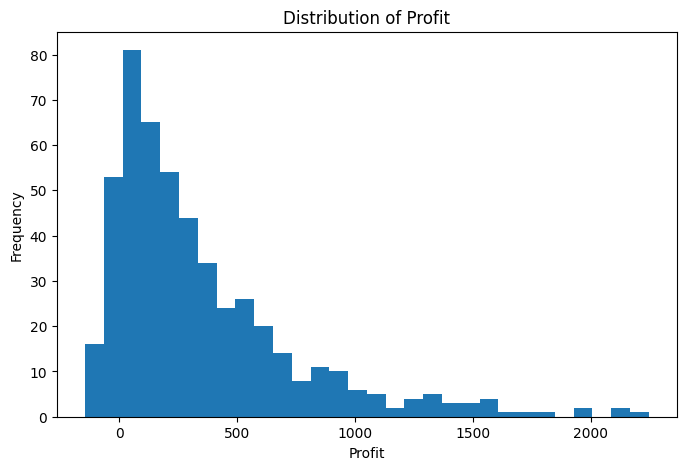

In [ ]:
plt.figure(figsize=(8, 5))
plt.hist(df["Profit"], bins=30)
plt.title("Distribution of Profit")
plt.xlabel("Profit")
plt.ylabel("Frequency")
plt.show()

In [ ]:
regions = df["Region"].unique()
region_sales = [df[df["Region"] == r]["Sales"] for r in regions]

/tmp/ipykernel_9867/4076274434.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(region_sales, labels=regions)


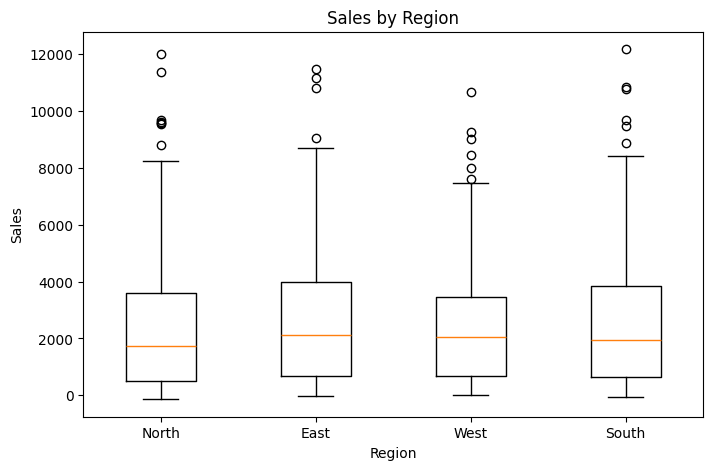

In [ ]:
plt.figure(figsize=(8, 5))
plt.boxplot(region_sales, labels=regions)
plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Sales")
plt.show()

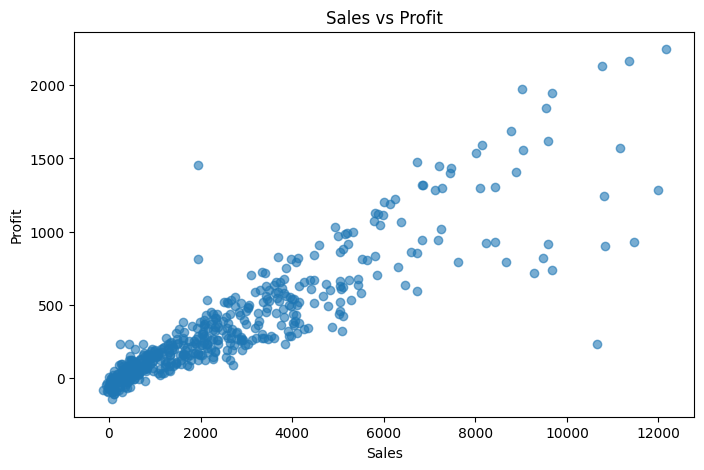

In [ ]:
plt.figure(figsize=(8, 5))
plt.scatter(df["Sales"], df["Profit"], alpha=0.6)
plt.title("Sales vs Profit")
plt.xlabel("Sales")
plt.ylabel("Profit")
plt.show()

In [ ]:
def detect_outliers_iqr(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    outliers = series[(series < lower) | (series > upper)]
    return lower, upper, outliers

for col in ["Sales", "Profit"]:
    lower, upper, outliers = detect_outliers_iqr(df[col])
    print(f"\n OUTLIER ANALYSIS: {col} ")
    print(f"Lower bound: {lower:.2f}")
    print(f"Upper bound: {upper:.2f}")
    print(f"Number of outliers: {len(outliers)}")


 OUTLIER ANALYSIS: Sales 
Lower bound: -4078.81
Upper bound: 8371.91
Number of outliers: 23

 OUTLIER ANALYSIS: Profit 
Lower bound: -572.58
Upper bound: 1148.10
Number of outliers: 29


In [ ]:
# confidence intervals
def confidence_interval_mean(data, confidence=0.95):
    data = np.array(data)
    n = len(data)
    mean = np.mean(data)
    sem = stats.sem(data)
    margin = sem * stats.t.ppf((1 + confidence) / 2, n - 1)
    return mean, mean - margin, mean + margin

sales_mean, sales_ci_low, sales_ci_high = confidence_interval_mean(df["Sales"])
profit_mean, profit_ci_low, profit_ci_high = confidence_interval_mean(df["Profit"])

print("\n 95% CONFIDENCE INTERVALS ")
print(f"Sales Mean: {sales_mean:.2f}, 95% CI: ({sales_ci_low:.2f}, {sales_ci_high:.2f})")
print(f"Profit Mean: {profit_mean:.2f}, 95% CI: ({profit_ci_low:.2f}, {profit_ci_high:.2f})")




 95% CONFIDENCE INTERVALS 
Sales Mean: 2578.89, 95% CI: (2360.47, 2797.30)
Profit Mean: 349.12, 95% CI: (313.56, 384.68)


In [ ]:
# Shapiro-Wilk is sensitive for large samples, so using a sample if dataset is large
sample_sales = df["Sales"].sample(min(500, len(df)), random_state=42)
sample_profit = df["Profit"].sample(min(500, len(df)), random_state=42)

sales_shapiro = stats.shapiro(sample_sales)
profit_shapiro = stats.shapiro(sample_profit)

print("\n===== NORMALITY TESTS (Shapiro-Wilk) =====")
print(f"Sales: statistic={sales_shapiro.statistic:.4f}, p-value={sales_shapiro.pvalue:.4f}")
print(f"Profit: statistic={profit_shapiro.statistic:.4f}, p-value={profit_shapiro.pvalue:.4f}")

# Interpretation helper
def interpret_pvalue(p, alpha=0.05):
    return "Reject null hypothesis" if p < alpha else "Fail to reject null hypothesis"

print("\nNormality interpretation:")
print("Sales:", interpret_pvalue(sales_shapiro.pvalue), "- likely not normally distributed" if sales_shapiro.pvalue < 0.05 else "- may be approximately normal")
print("Profit:", interpret_pvalue(profit_shapiro.pvalue), "- likely not normally distributed" if profit_shapiro.pvalue < 0.05 else "- may be approximately normal")


===== NORMALITY TESTS (Shapiro-Wilk) =====
Sales: statistic=0.8501, p-value=0.0000
Profit: statistic=0.8231, p-value=0.0000

Normality interpretation:
Sales: Reject null hypothesis - likely not normally distributed
Profit: Reject null hypothesis - likely not normally distributed


In [ ]:
# Question:
# Does high discount significantly affect sales?

high_discount_sales = df[df["Discount"] > 0.15]["Sales"]
low_discount_sales = df[df["Discount"] <= 0.15]["Sales"]

# Independent t-test
t_stat, p_val = ttest_ind(high_discount_sales, low_discount_sales, equal_var=False)

print("\n HYPOTHESIS TEST: HIGH DISCOUNT VS LOW DISCOUNT SALES ")
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_val:.4f}")

if p_val < 0.05:
    print("Conclusion: Significant difference in sales between high discount and low discount groups.")
else:
    print("Conclusion: No statistically significant difference in sales between the two groups.")



 HYPOTHESIS TEST: HIGH DISCOUNT VS LOW DISCOUNT SALES 
T-statistic: -2.4146
P-value: 0.0161
Conclusion: Significant difference in sales between high discount and low discount groups.


In [ ]:
u_stat, p_u = mannwhitneyu(high_discount_sales, low_discount_sales, alternative="two-sided")
print("\nMann-Whitney U Test")
print(f"U-statistic: {u_stat:.4f}")
print(f"P-value: {p_u:.4f}")


Mann-Whitney U Test
U-statistic: 27493.0000
P-value: 0.0280


In [ ]:
# ANOVA
north = df[df["Region"] == "North"]["Sales"]
south = df[df["Region"] == "South"]["Sales"]
east = df[df["Region"] == "East"]["Sales"]
west = df[df["Region"] == "West"]["Sales"]

anova_stat, anova_p = f_oneway(north, south, east, west)

print(f"F-statistic: {anova_stat:.4f}")
print(f"P-value: {anova_p:.4f}")

if anova_p < 0.05:
    print("Conclusion: At least one region has significantly different average sales.")
else:
    print("Conclusion: No significant difference in average sales across regions.")

F-statistic: 0.2633
P-value: 0.8518
Conclusion: No significant difference in average sales across regions.


In [ ]:
contingency_table = pd.crosstab(df["Region"], df["High_Discount"])
chi2, chi_p, dof, expected = chi2_contingency(contingency_table)

print("\nCHI-SQUARE TEST: REGION VS HIGH DISCOUNT")
print("Contingency Table:")
print(contingency_table)
print(f"Chi-square statistic: {chi2:.4f}")
print(f"P-value: {chi_p:.4f}")
print(f"Degrees of freedom: {dof}")

if chi_p < 0.05:
    print("Conclusion: Region and high discount status are associated.")
else:
    print("Conclusion: No significant association between region and high discount status.")


CHI-SQUARE TEST: REGION VS HIGH DISCOUNT
Contingency Table:
High_Discount  No  Yes
Region                
East           68   56
North          78   57
South          62   56
West           63   60
Chi-square statistic: 1.2873
P-value: 0.7322
Degrees of freedom: 3
Conclusion: No significant association between region and high discount status.



CORRELATION MATRIX 
                  Sales    Profit  Discount  Quantity  Profit_Margin
Sales          1.000000  0.895046 -0.145321  0.548493       0.069194
Profit         0.895046  1.000000 -0.196007  0.498815       0.096099
Discount      -0.145321 -0.196007  1.000000 -0.041573      -0.011591
Quantity       0.548493  0.498815 -0.041573  1.000000       0.087262
Profit_Margin  0.069194  0.096099 -0.011591  0.087262       1.000000


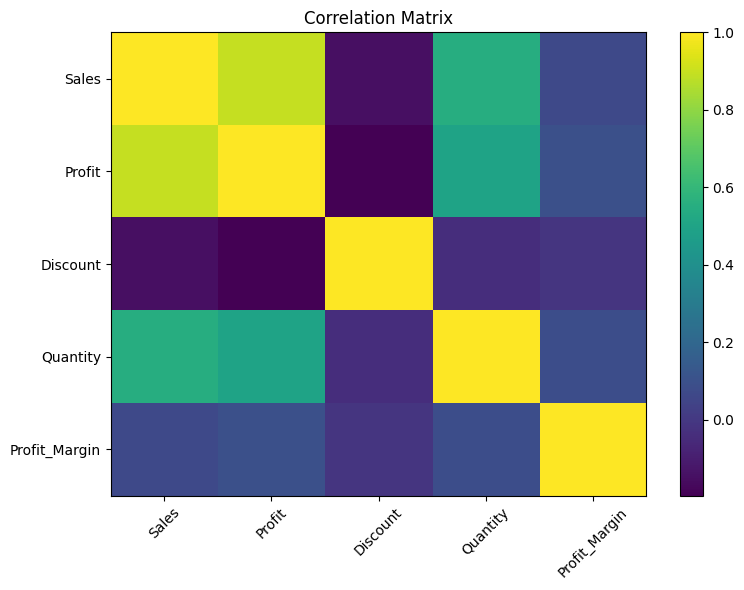

In [ ]:
corr_matrix = df[["Sales", "Profit", "Discount", "Quantity", "Profit_Margin"]].corr()

print("\nCORRELATION MATRIX ")
print(corr_matrix)

# Heatmap using matplotlib only
plt.figure(figsize=(8, 6))
plt.imshow(corr_matrix, interpolation="nearest", aspect="auto")
plt.colorbar()
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=45)
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()



 SIMPLE LINEAR REGRESSION: PREDICT PROFIT FROM SALES 
Coefficient: 0.1433
Intercept: -19.9563
R-squared: 0.8321
MAE: 92.4441
RMSE: 139.7034


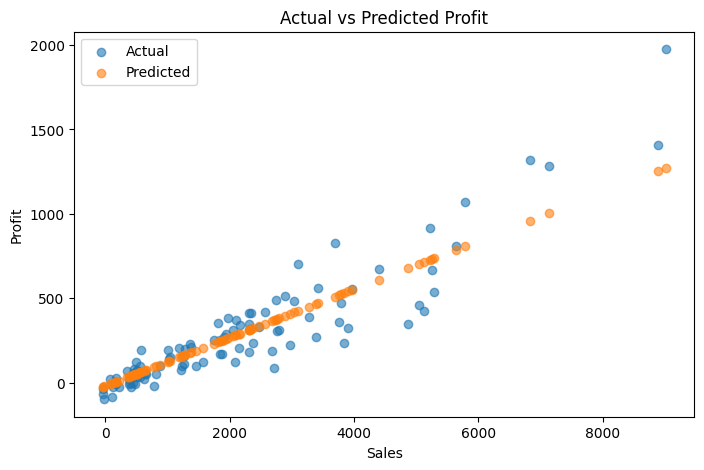

In [ ]:
X = df[["Sales"]]
y = df["Profit"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

y_pred = lin_reg.predict(X_test)

print("\n SIMPLE LINEAR REGRESSION: PREDICT PROFIT FROM SALES ")
print(f"Coefficient: {lin_reg.coef_[0]:.4f}")
print(f"Intercept: {lin_reg.intercept_:.4f}")
print(f"R-squared: {r2_score(y_test, y_pred):.4f}")
print(f"MAE: {mean_absolute_error(y_test, y_pred):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}")

plt.figure(figsize=(8, 5))
plt.scatter(X_test, y_test, alpha=0.6, label="Actual")
plt.scatter(X_test, y_pred, alpha=0.6, label="Predicted")
plt.title("Actual vs Predicted Profit")
plt.xlabel("Sales")
plt.ylabel("Profit")
plt.legend()
plt.show()
